In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/MyDrive/Colab Notebooks/yo/

/content/drive/MyDrive/Colab Notebooks/yo


## Business Problem Understanding
- to predict based on the input columns if a person joins this organization what likekly can be his salary

In [5]:
df= pd.read_csv("job_salary_prediction_dataset.csv")
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [6]:
df1 = df.copy()

# Data Understanding and EDA

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [8]:
df.isnull().sum()

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


In [9]:
df['job_title'].unique()

array(['AI Engineer', 'Data Analyst', 'Frontend Developer',
       'Business Analyst', 'Product Manager', 'Backend Developer',
       'Machine Learning Engineer', 'DevOps Engineer',
       'Software Engineer', 'Cybersecurity Analyst', 'Data Scientist',
       'Cloud Engineer'], dtype=object)

In [10]:
df['job_title'].value_counts()

,count
job_title,
Backend Developer,21125
Cybersecurity Analyst,20959
Product Manager,20950
AI Engineer,20945
Data Scientist,20890
DevOps Engineer,20889
Software Engineer,20876
Data Analyst,20722
Cloud Engineer,20686


In [11]:
df['experience_years'].value_counts()

,count
experience_years,
14,12166
18,12102
15,12052
1,12011
4,12001
7,11981
20,11958
2,11950
12,11944


In [12]:
df['education_level'].value_counts()

,count
education_level,
Master,50352
High School,50065
Bachelor,49950
PhD,49857
Diploma,49776


In [13]:
df['skills_count'].value_counts()

,count
skills_count,
14,13298
9,13267
8,13266
1,13250
3,13248
17,13214
16,13213
5,13196
6,13184


In [14]:
df['industry'].value_counts()

,count
industry,
Finance,25393
Consulting,25258
Media,25034
Manufacturing,25024
Technology,24903
Government,24901
Healthcare,24898
Education,24889
Telecom,24859


In [15]:
df['company_size'].value_counts()

,count
company_size,
Large,50254
Small,50235
Medium,50027
Enterprise,49875
Startup,49609


In [16]:
df['location'].value_counts()

,count
location,
Australia,25258
Canada,25165
Sweden,25100
Remote,25065
Singapore,25035
USA,24931
UK,24927
India,24895
Netherlands,24861


In [17]:
df['remote_work'].value_counts()

,count
remote_work,
No,83621
Hybrid,83476
Yes,82903


In [18]:
df['certifications'].value_counts()

,count
certifications,
0,42015
3,41974
2,41744
1,41574
4,41467
5,41226


In [19]:
df['salary'].describe()

,salary
count,250000.000000
mean,145718.080524
std,37407.952729
min,31867.000000
25%,119358.000000
50%,143453.000000
75%,169492.000000
max,333046.000000


In [20]:
df['salary'].skew()

np.float64(0.3794009747285935)

In [21]:
df.isna().sum()

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


In [22]:
continuous = ['salary']
discrete_count= ['skills_count','certifications']
descrete_categorical= ['job_title','experience_years','education_level','industry','company_size','location','remote_work']

## For Discrete variables

In [23]:
df[descrete_categorical].describe()

,experience_years
count,250000.000000
mean,10.005408
std,6.060602
min,0.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,20.000000


In [24]:
df[discrete_count].describe()

,skills_count,certifications
count,250000.000000,250000.000000
mean,9.997812,2.491928
std,5.479288,1.706475
min,1.000000,0.000000
25%,5.000000,1.000000
50%,10.000000,2.000000
75%,15.000000,4.000000
max,19.000000,5.000000


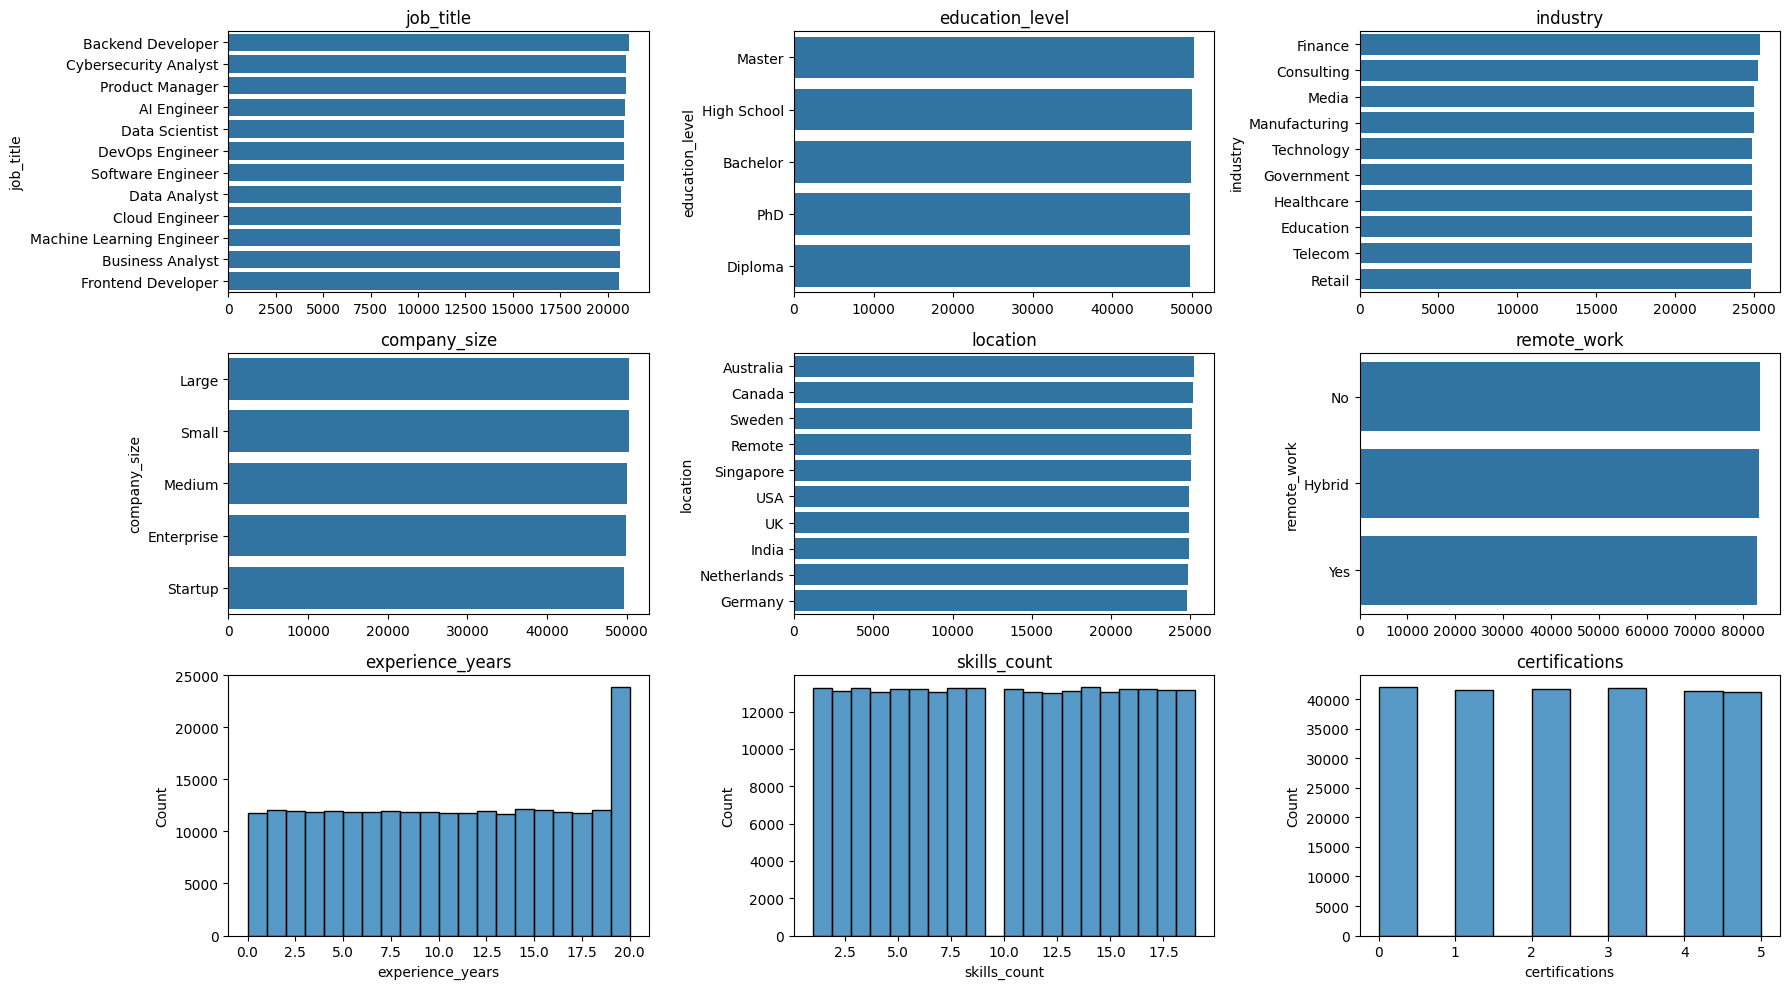

In [25]:
plt.figure(figsize=(18,10))

cat_cols = ['job_title','education_level','industry',
            'company_size','location','remote_work']

for i, col in enumerate(cat_cols, 1):
    plt.subplot(3,3,i)
    counts = df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index)
    plt.title(col)

# numeric-discrete columns
plt.subplot(3,3,7)
sns.histplot(df['experience_years'], bins=20)
plt.title('experience_years')

plt.subplot(3,3,8)
sns.histplot(df['skills_count'], bins=20)
plt.title('skills_count')

plt.subplot(3,3,9)
sns.histplot(df['certifications'], bins=10)
plt.title('certifications')

plt.tight_layout()
plt.show()

In [26]:
df.groupby('job_title')['salary'].agg(['mean','median','min','max','count'])

,mean,median,min,max,count
job_title,,,,,
AI Engineer,173498.480640,171674.0,66371,333046,20945
Backend Developer,139202.768663,136678.0,46304,290512,21125
Business Analyst,122551.231354,120562.0,39285,264567,20648
Cloud Engineer,152102.535290,150005.0,45030,292855,20686
Cybersecurity Analyst,148697.695548,146737.0,54224,303178,20959
Data Analyst,119891.696603,118079.5,31867,249354,20722
Data Scientist,147258.214409,145231.5,51349,288049,20890
DevOps Engineer,149959.266791,148021.0,54985,304968,20889
Frontend Developer,132653.842485,130619.0,44964,277053,20633


Text(0.5, 1.0, 'Job Title vs Salary')

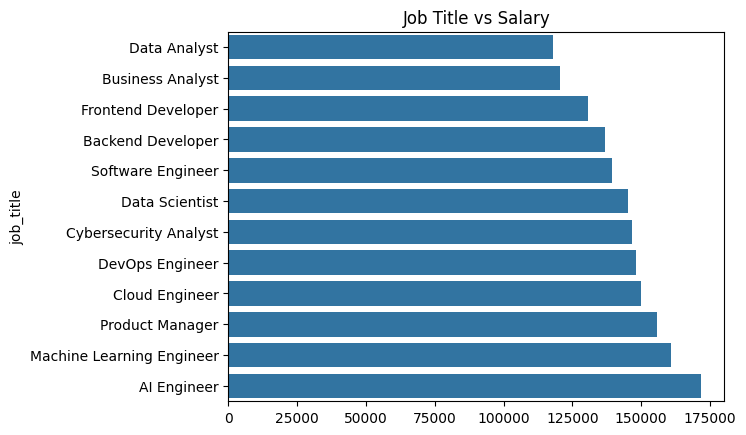

In [27]:
job_salary = df.groupby('job_title')['salary'].median().sort_values()
sns.barplot(x=job_salary.values, y=job_salary.index)
plt.title("Job Title vs Salary")

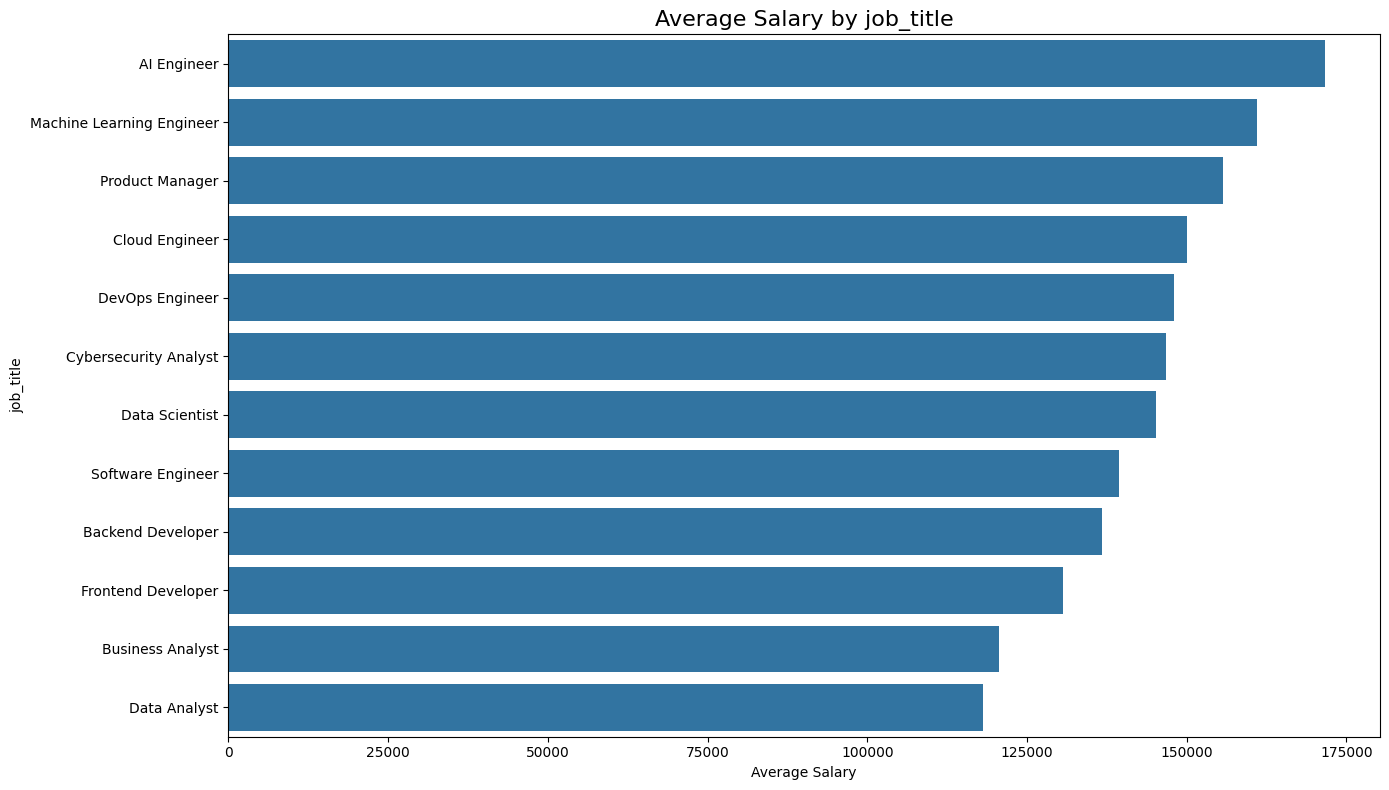

In [28]:
job_salary = df.groupby('job_title')['salary'].median().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=job_salary.values,
    y=job_salary.index
)

plt.title("Average Salary by job_title", fontsize=16)
plt.xlabel("Average Salary")
plt.ylabel("job_title")

plt.tight_layout()
plt.show()

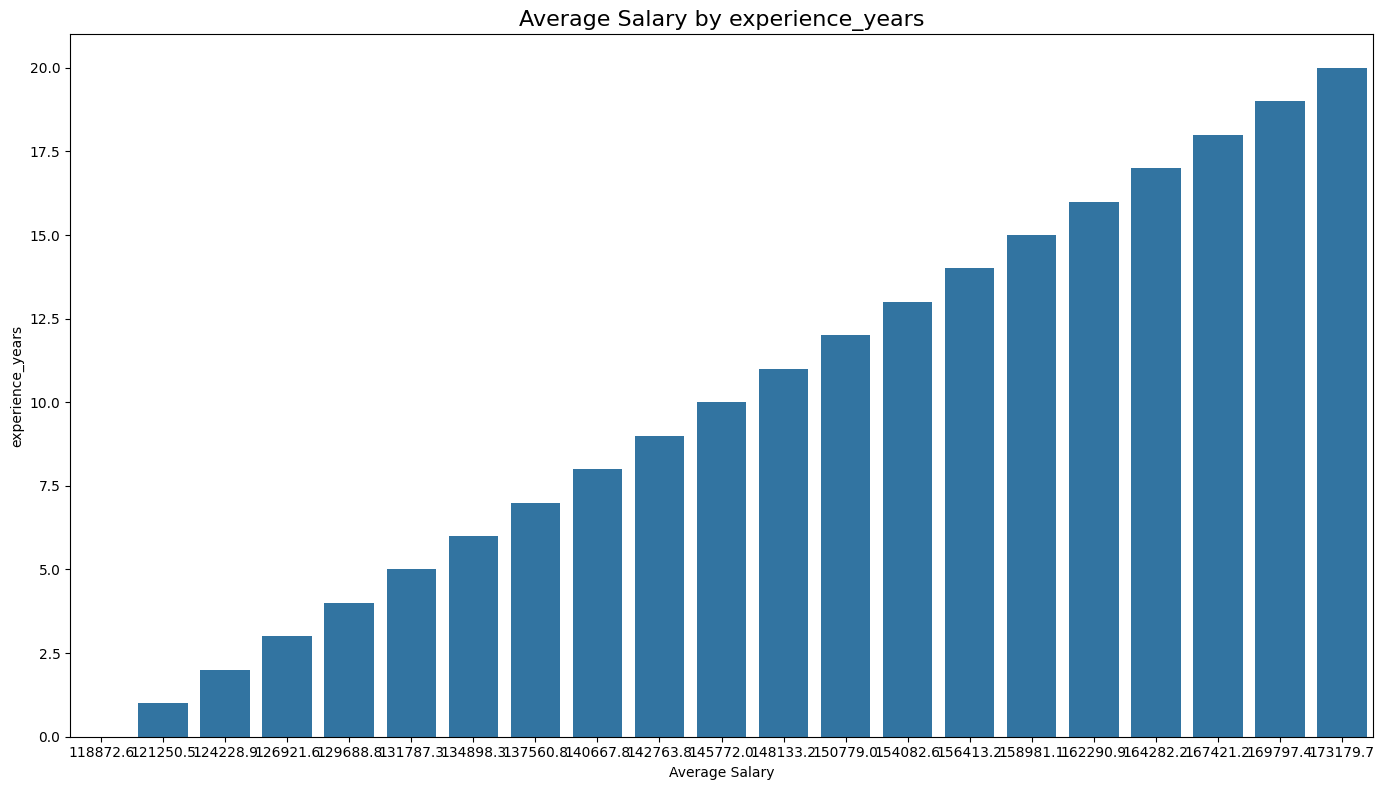

In [29]:
skills_counts = df.groupby('experience_years')['salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=skills_counts.values.round(1),
    y=skills_counts.index
)

plt.title("Average Salary by experience_years", fontsize=16)
plt.xlabel("Average Salary")
plt.ylabel("experience_years")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'education_level vs Salary')

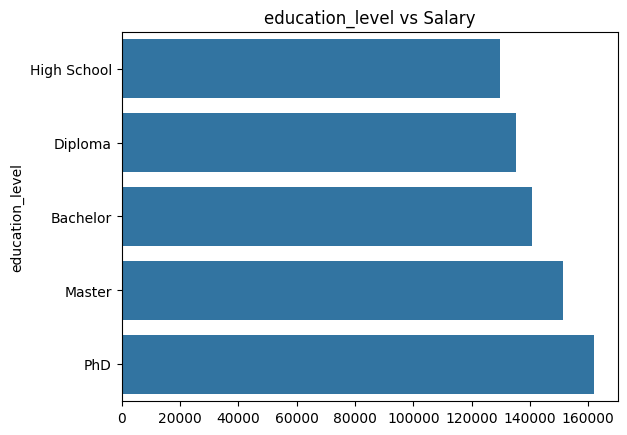

In [30]:
job_salary = df.groupby('education_level')['salary'].median().sort_values()
sns.barplot(x=job_salary.values, y=job_salary.index)
plt.title("education_level vs Salary")

In [31]:
pd.crosstab(df['job_title'], df['education_level'])

education_level,Bachelor,Diploma,High School,Master,PhD
job_title,,,,,
AI Engineer,4212,4178,4211,4192,4152
Backend Developer,4179,4200,4346,4333,4067
Business Analyst,4079,4065,4135,4230,4139
Cloud Engineer,4198,4120,4248,4068,4052
Cybersecurity Analyst,4182,4203,4141,4279,4154
Data Analyst,4206,4126,4088,4161,4141
Data Scientist,4145,4246,4135,4186,4178
DevOps Engineer,4038,4168,4201,4248,4234
Frontend Developer,4103,4112,4113,4106,4199


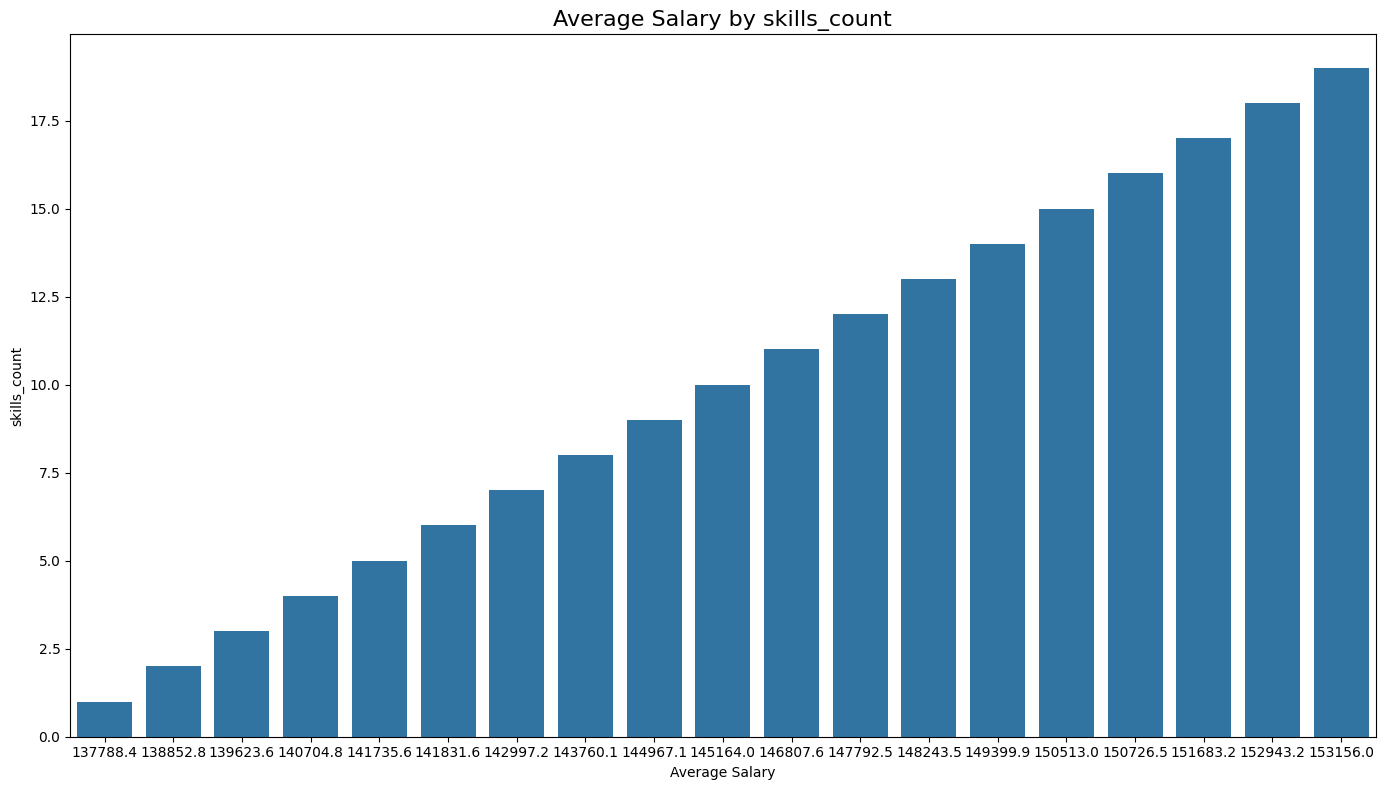

In [32]:
skills_counts = df.groupby('skills_count')['salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=skills_counts.values.round(1),
    y=skills_counts.index
)

plt.title("Average Salary by skills_count", fontsize=16)
plt.xlabel("Average Salary")
plt.ylabel("skills_count")

plt.tight_layout()
plt.show()

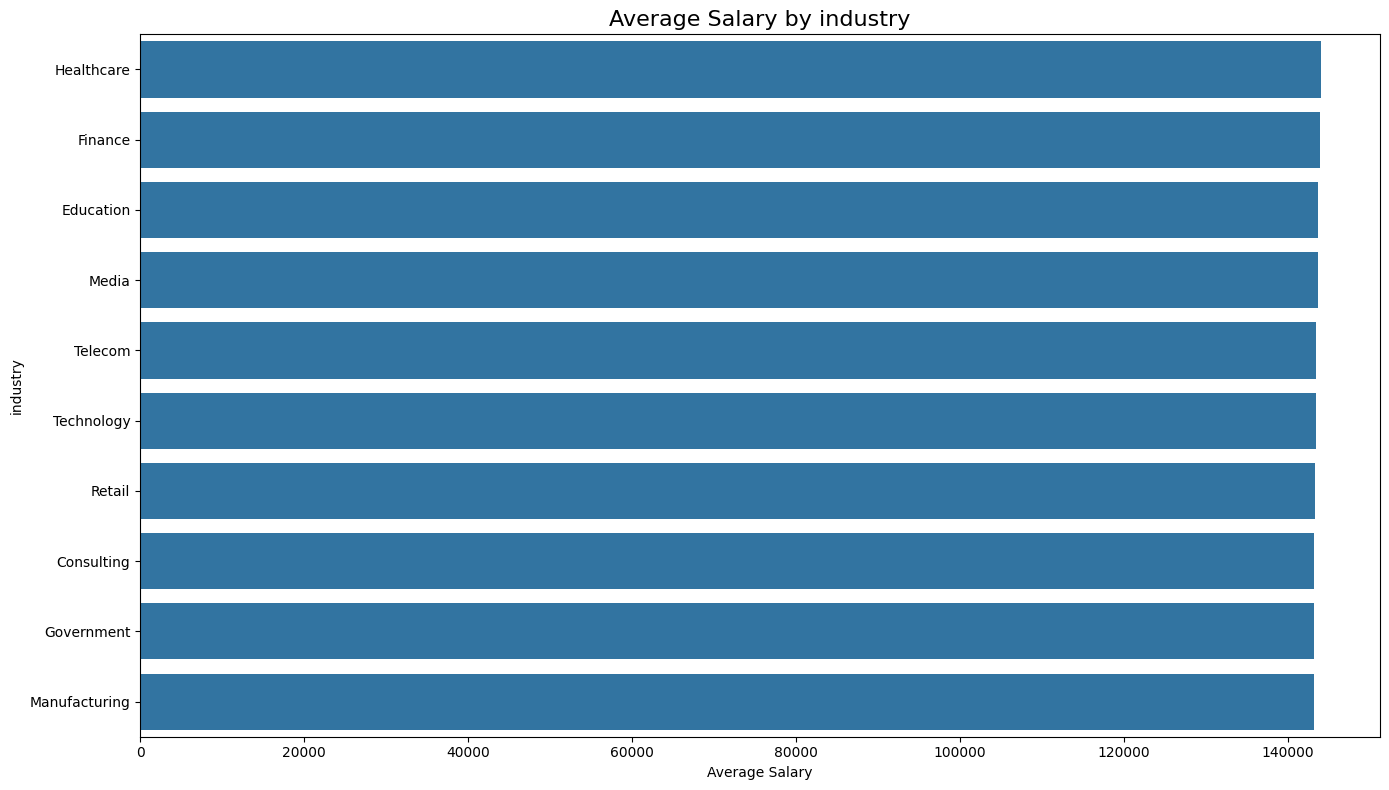

In [33]:
skills_counts = df.groupby('industry')['salary'].median().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=skills_counts.values,
    y=skills_counts.index
)

plt.title("Average Salary by industry", fontsize=16)
plt.xlabel("Average Salary")
plt.ylabel("industry")

plt.tight_layout()
plt.show()

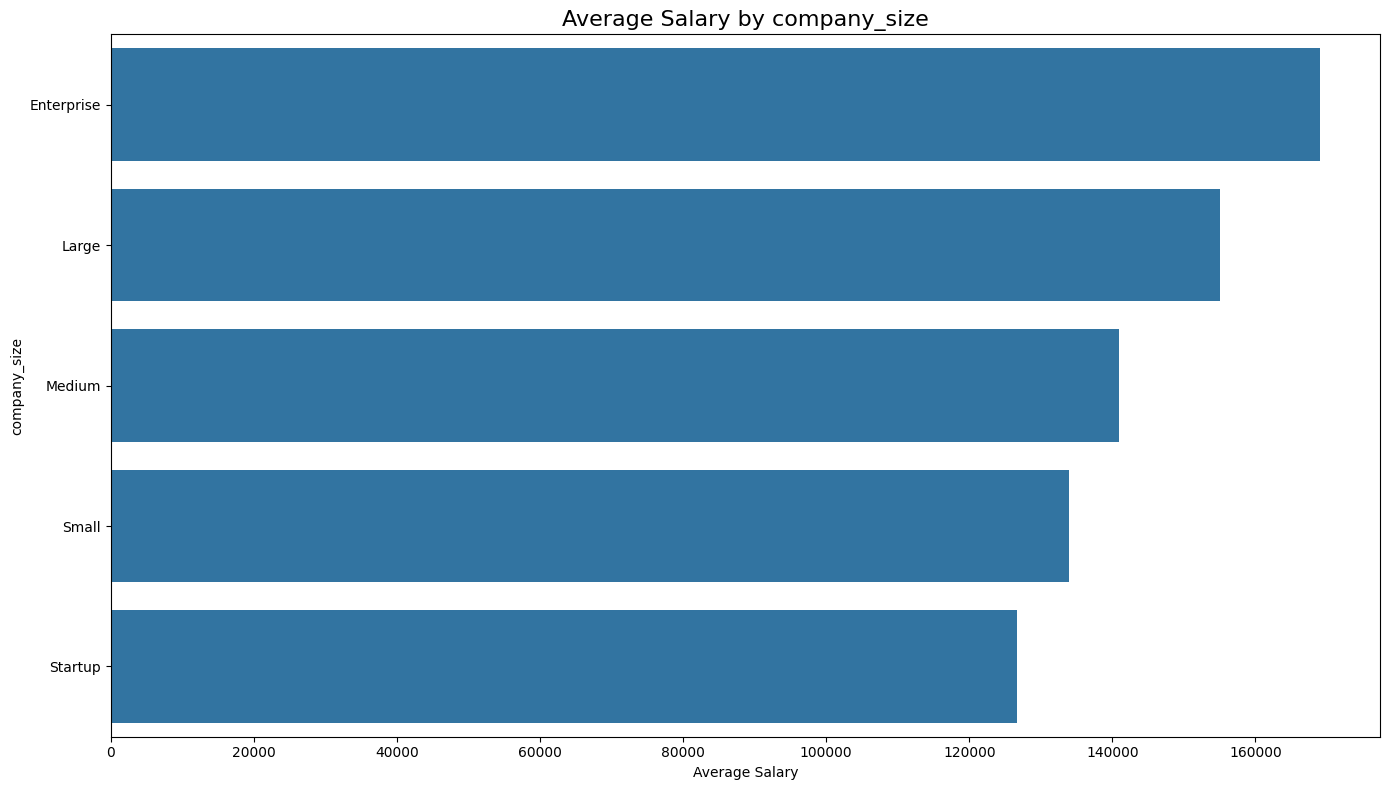

In [34]:
skills_counts = df.groupby('company_size')['salary'].median().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=skills_counts.values.round(1),
    y=skills_counts.index
)

plt.title("Average Salary by company_size", fontsize=16)
plt.xlabel("Average Salary")
plt.ylabel("company_size")

plt.tight_layout()
plt.show()

In [35]:
pd.crosstab(df['experience_years'], df['company_size'])

company_size,Enterprise,Large,Medium,Small,Startup
experience_years,,,,,
0,2428,2362,2343,2329,2342
1,2388,2390,2392,2462,2379
2,2331,2443,2422,2373,2381
3,2303,2356,2445,2394,2392
4,2413,2479,2349,2437,2323
5,2404,2372,2402,2345,2339
6,2385,2313,2355,2369,2438
7,2366,2404,2424,2400,2387
8,2419,2410,2295,2352,2346


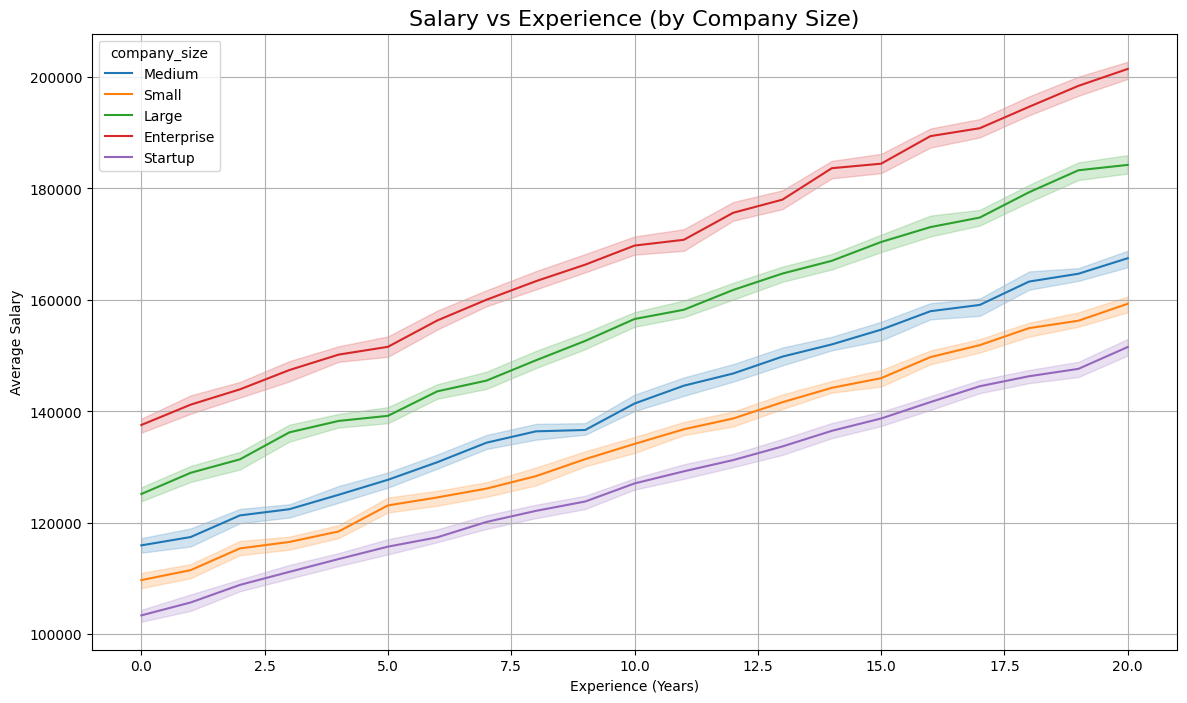

In [36]:
plt.figure(figsize=(14,8))

sns.lineplot(
    data=df,
    x='experience_years',
    y='salary',
    hue='company_size',
    estimator='median'   # important: averages salary
)

plt.title("Salary vs Experience (by Company Size)", fontsize=16)
plt.xlabel("Experience (Years)")
plt.ylabel("Average Salary")

plt.grid(True)
plt.show()

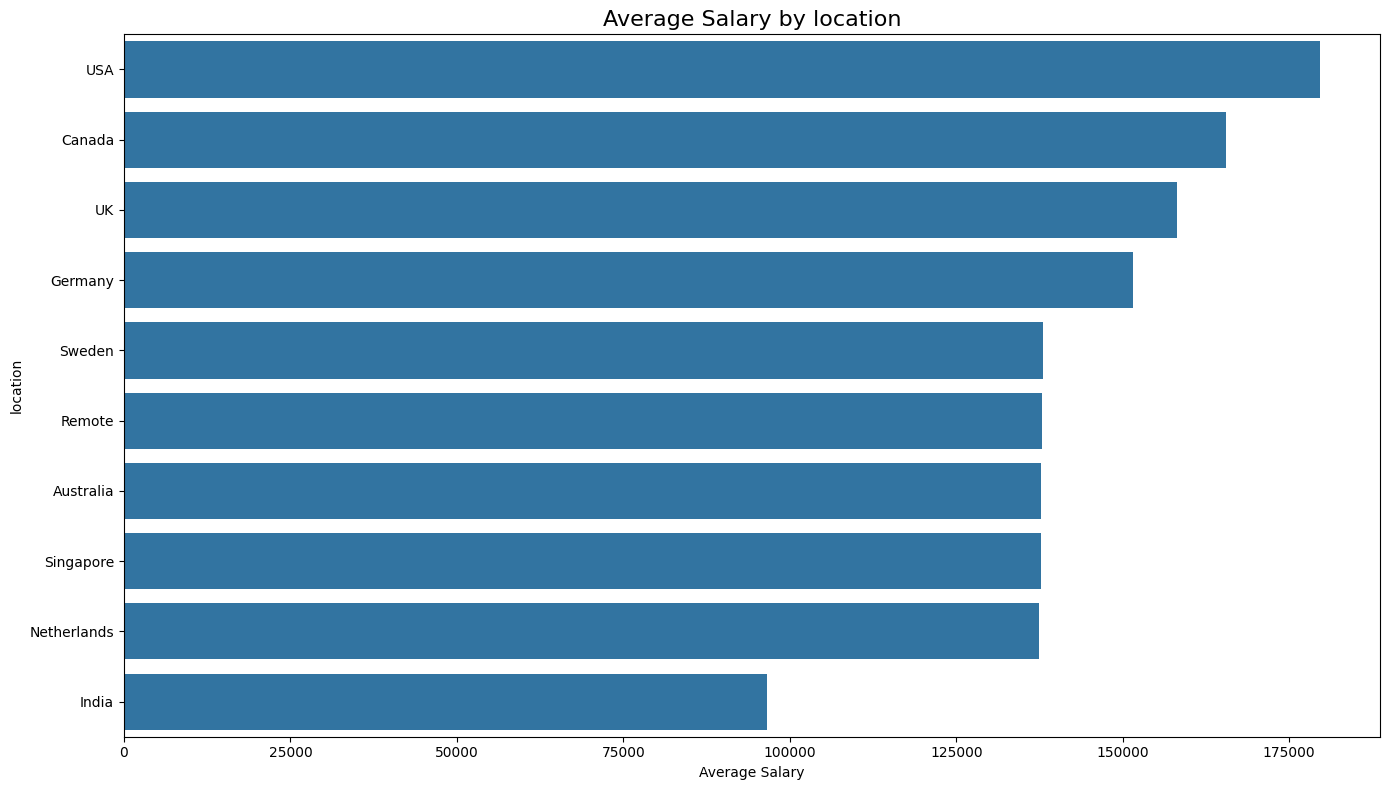

In [37]:
skills_counts = df.groupby('location')['salary'].median().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=skills_counts.values,
    y=skills_counts.index
)

plt.title("Average Salary by location", fontsize=16)
plt.xlabel("Average Salary")
plt.ylabel("location")

plt.tight_layout()
plt.show()

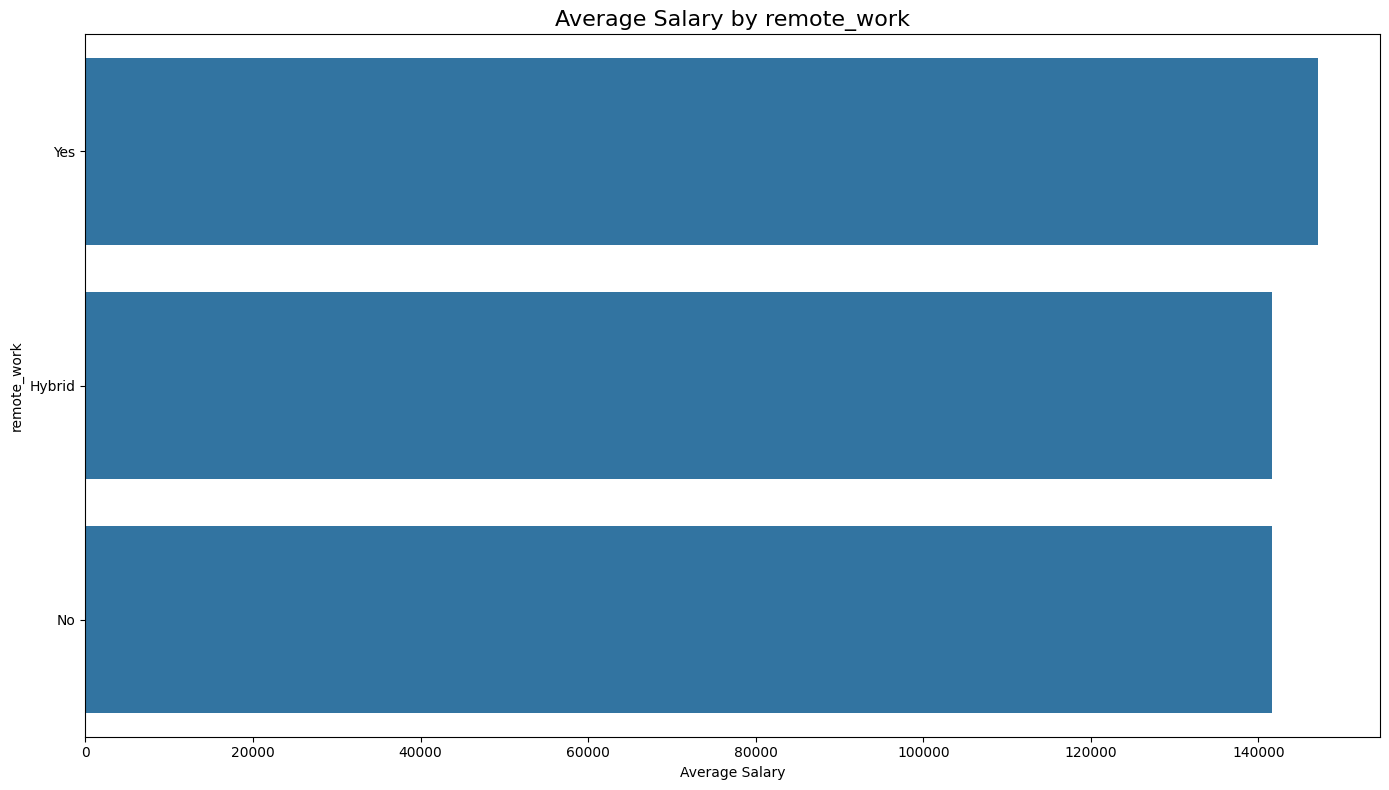

In [38]:
skills_counts = df.groupby('remote_work')['salary'].median().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=skills_counts.values,
    y=skills_counts.index
)

plt.title("Average Salary by remote_work", fontsize=16)
plt.xlabel("Average Salary")
plt.ylabel("remote_work")

plt.tight_layout()
plt.show()

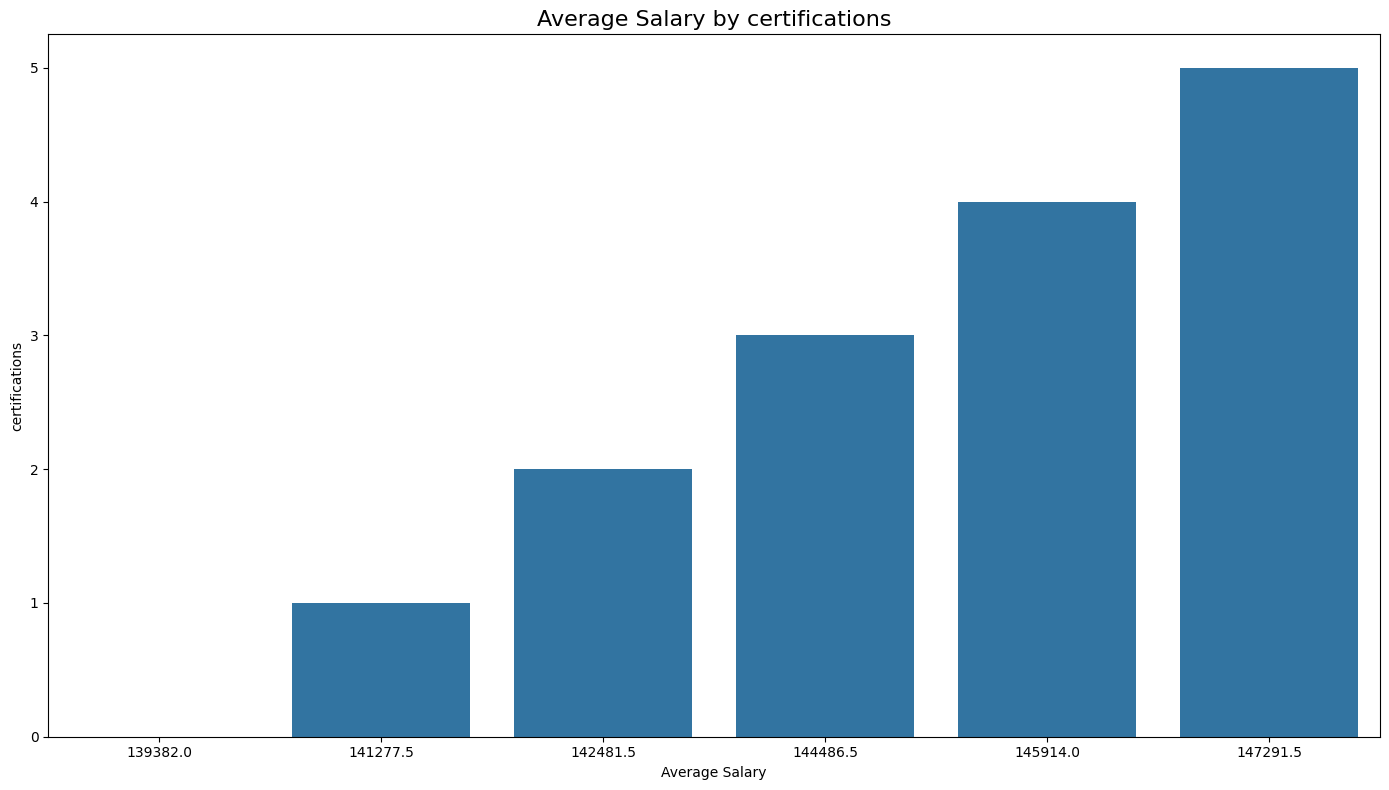

In [39]:
skills_counts = df.groupby('certifications')['salary'].median().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=skills_counts.values,
    y=skills_counts.index
)

plt.title("Average Salary by certifications", fontsize=16)
plt.xlabel("Average Salary")
plt.ylabel("certifications")

plt.tight_layout()
plt.show()

In [40]:
df.groupby('job_title')['salary'].agg(['mean','median','min','max','count'])

,mean,median,min,max,count
job_title,,,,,
AI Engineer,173498.480640,171674.0,66371,333046,20945
Backend Developer,139202.768663,136678.0,46304,290512,21125
Business Analyst,122551.231354,120562.0,39285,264567,20648
Cloud Engineer,152102.535290,150005.0,45030,292855,20686
Cybersecurity Analyst,148697.695548,146737.0,54224,303178,20959
Data Analyst,119891.696603,118079.5,31867,249354,20722
Data Scientist,147258.214409,145231.5,51349,288049,20890
DevOps Engineer,149959.266791,148021.0,54985,304968,20889
Frontend Developer,132653.842485,130619.0,44964,277053,20633


## For continuous Variable

In [41]:
df[continuous].describe()

,salary
count,250000.000000
mean,145718.080524
std,37407.952729
min,31867.000000
25%,119358.000000
50%,143453.000000
75%,169492.000000
max,333046.000000


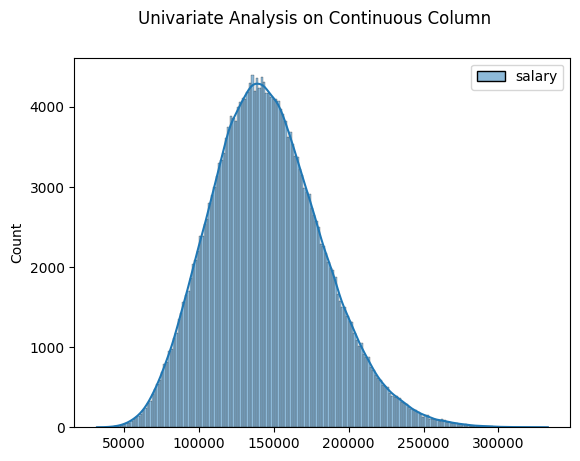

In [42]:
sns.histplot(df[continuous],kde=True)
plt.suptitle("Univariate Analysis on Continuous Column")
plt.show()

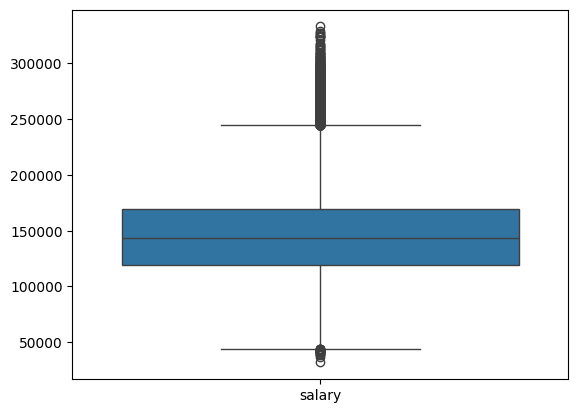

In [43]:
sns.boxplot(df[continuous])
plt.show()

- observations:
1. Salary increases with increased years of experience
2. AI engineers have more salary
3. People with Phds are paid more...<strike> (they are ML/AI enginners probably)</strike>
4. Most phd people are product managers...WHATTT
5. more skill more moneyyy
6. No such big difference of salaries between industries
7. Enterprise people have more salaries
8. Median salary of Enterprise people are much higher than rest type of companies.
9. USA people have more median salary , salary of [Sweden,Australia,Singapore,Netherlands, Remote] are in the same range. India people are the least paid.
10. Remote working people have more salary then hybrid or non remote working people.
11. People with 5 certifications have more median salary
12. Salary has outliers... but the outliers are moneytary... so people can have more salary hence we retained this and worked with respect to median.

## Data Cleaning , Scaling and Transformation  is not required as data is clean and doesnot have skewness.

## Data Encoding

# Ordinal

In [44]:
df["company_size"] = df["company_size"].replace({"Startup":0,"Small":1,"Medium":2,"Large":3,"Enterprise":4})

In [45]:
df["education_level"] = df["education_level"].replace({"High School":0,"Diploma":1,"Bachelor":2,"Master":3,"PhD":4})

In [46]:
inp = df.drop("salary",axis=1)
inp

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications
0,AI Engineer,10,2,2,Healthcare,2,India,Hybrid,2
1,Data Analyst,5,2,17,Telecom,1,Australia,No,0
2,Frontend Developer,18,4,4,Media,2,Singapore,No,1
3,Business Analyst,19,4,13,Retail,2,Canada,Yes,0
4,Product Manager,15,2,7,Manufacturing,3,Sweden,Yes,0
...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,4,2,Telecom,4,India,No,1
249996,Frontend Developer,20,4,7,Telecom,0,Remote,No,2
249997,Business Analyst,1,2,12,Retail,4,India,Yes,0
249998,Data Scientist,0,0,2,Consulting,1,Sweden,Hybrid,5


In [47]:
data = pd.get_dummies(inp,drop_first=True).astype(int)

In [48]:
data.head()

,experience_years,education_level,skills_count,company_size,certifications,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,2,2,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,5,2,17,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,18,4,4,2,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
3,19,4,13,2,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,15,2,7,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


# X & y

In [49]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,2,2,Healthcare,2,India,Hybrid,2,109413
1,Data Analyst,5,2,17,Telecom,1,Australia,No,0,93764
2,Frontend Developer,18,4,4,Media,2,Singapore,No,1,148123
3,Business Analyst,19,4,13,Retail,2,Canada,Yes,0,189123
4,Product Manager,15,2,7,Manufacturing,3,Sweden,Yes,0,165069


In [50]:
X = data
y = df['salary']

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Modelling : ElasticNet Regression

In [52]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 14)

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet

In [54]:
param_grid = {
    "alpha": np.logspace(-4, 0, 20),
    "l1_ratio": [0.1, 0.5, 0.9]
}

model_hp = GridSearchCV(
    ElasticNet(),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

model_hp.fit(X_train, y_train)
model_hp.best_params_

{'alpha': np.float64(0.0001), 'l1_ratio': 0.9}

In [55]:
enr_best = ElasticNet(alpha=0.0001, l1_ratio=0.9)
enr_best.fit(X_train,y_train)
print("Intercept:",enr_best.intercept_)
print("Coefficients:",enr_best.coef_)

ypred_train_enr = enr_best.predict(X_train)

from sklearn.metrics import r2_score
print("Train R2:",r2_score(y_train,ypred_train_enr))

from sklearn.model_selection import cross_val_score
print("CV Score: ",cross_val_score(enr_best,X_train,y_train,cv=5).mean())

ypred_test_enr = enr_best.predict(X_test)
print("Test R2:", r2_score(y_test,ypred_test_enr))

Intercept: 88587.94966575333
Coefficients: [ 2.69689430e+03  8.06560287e+03  8.57298088e+02  1.05900930e+04
  1.61306569e+03 -3.42892836e+04 -5.14382888e+04 -2.13974560e+04
 -2.46489357e+04 -5.36516693e+04 -2.68758462e+04 -2.36481278e+04
 -4.07738503e+04 -1.06325401e+04 -1.60533134e+04 -3.21778940e+04
  7.92853506e+00  4.60730555e+01  1.51190116e+02  7.87375460e+01
  2.85716218e+00  8.65022738e+01  7.85268820e+01  3.78126768e+01
  1.06706765e+02  2.79398884e+04  1.40126137e+04 -4.19133331e+04
 -2.40112226e+01  5.60060150e+01  1.33903708e+01 -8.11768319e+00
  2.09809401e+04  4.19661687e+04  2.75043655e+01  5.34671500e+03]
Train R2: 0.9553119792060766
CV Score:  0.9552910015564506
Test R2: 0.9559173689366769
